```text
Reporting
├── Import & Setup
├── Reporting preparation
└── Reporting
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import estimate_capital_reduction, show_approval_vs_reduction
from src.feature_engineering import create_target_def12
from src.modelling import apply_pipe, apply_pipe_LGD, estimate_capital
from src.plots import my_heatmap, plot_distribution
from src.preprocessing import my_input_load, ReplaceMinusOne
from src.reporting import create_risk_report

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = my_input_load(2021, 2021)
portfolio, dr_summary = create_target_def12(portfolio)

LoanDate range:     2021-01-01 00:00:00 2021-12-31 00:00:00
+12 months:         2022-01-01 00:00:00 2022-12-31 00:00:00
DefaultDate range:  2021-04-16 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2021,30266,3694,0.122051


In [4]:
# load PD, LGD pipelines

import joblib
pipeline_pd  = joblib.load("../models/PIPELINE_PD_ver_012.pkl")
pipeline_lgd = joblib.load("../models/PIPELINE_LGD_Amount.pkl")

# estimate PD, LGD

portfolio = apply_pipe(portfolio, pipeline_pd)
portfolio = apply_pipe_LGD(portfolio, pipeline_lgd)

# run Monte-Carlo

portfolio_cap, loss_summary, el_summary, loss_fig = estimate_capital(portfolio, method="monte-carlo", column_lgd="LGD", allocate=True, verbose=False, show_plot=False)

## Reporting Preparation

In [5]:
# Portfolio Overview

overview = {
    "Year(s)": portfolio["LoanYear"].unique(),
    "Nr. of Exposures": f"{len(portfolio):,}",
    "Total Exposure": f"{portfolio['Amount'].sum():,.0f}",
    "Mean PD": f"{portfolio['PD'].mean():.2%}",
    "Mean LGD": f"{portfolio['LGD'].mean():.2%}",
}
display(pd.Series(overview))

# plots: Distributions

ead_distribution = plot_distribution(portfolio, "Amount")
pd_distribution  = plot_distribution(portfolio, "PD")
lgd_distribution = plot_distribution(portfolio, "LGD")

Year(s)                 [2021]
Nr. of Exposures        30,266
Total Exposure      85,557,401
Mean PD                 15.64%
Mean LGD                12.52%
dtype: object

In [ ]:
# Portfolio Risk

expected_loss    = el_summary["EL (deterministic)"]
expected_loss_mc = el_summary["EL (MC-simulated)"]
var_999          = loss_summary["VaR 99.9%"]
economic_capital = loss_summary["Economic Capital"]

# plots: Capital Allocation

expected_loss_by_pd_lgd = my_heatmap(portfolio_cap, variable="EL" , column_lgd="LGD", show=False)
econo_capital_by_pd_lgd = my_heatmap(portfolio_cap, variable="CAP", column_lgd="LGD", show=False)

selected variable:  EL
selected variable:  CAP


In [ ]:
# Portfolio Strategy

reduction = estimate_capital_reduction(portfolio, [1.00, 0.25, 0.20, 0.15, 0.10, 0.08, 0.05])

# plot

approval_vs_reduction = show_approval_vs_reduction(reduction, show_plot=False)


running Monte-Carlo...  PD threshold:  1.0
running Monte-Carlo...  PD threshold:  0.25
running Monte-Carlo...  PD threshold:  0.2
running Monte-Carlo...  PD threshold:  0.15
running Monte-Carlo...  PD threshold:  0.1
running Monte-Carlo...  PD threshold:  0.08
running Monte-Carlo...  PD threshold:  0.05


PD Threshold,Approval Rate,Portfolio EAD,Expected Loss,Expected Loss (MC),Economic Capital,EL Reduction,EC Reduction
1.00,100.0%,85.6 M€,8.39 M€,8.40 M€,460 k€,0 %,0 %
0.25,88.9%,70.9 M€,5.77 M€,5.77 M€,356 k€,31 %,23 %
0.20,78.4%,59.1 M€,4.33 M€,4.33 M€,315 k€,48 %,31 %
0.15,56.4%,37.8 M€,2.31 M€,2.31 M€,230 k€,72 %,50 %
0.10,22.3%,12.6 M€,0.56 M€,0.56 M€,106 k€,93 %,77 %
0.08,10.2%,5.4 M€,0.20 M€,0.20 M€,63 k€,98 %,86 %
0.05,1.3%,0.6 M€,0.01 M€,0.01 M€,16 k€,100 %,97 %


## Reporting

In [8]:
# create PDF

create_risk_report(overview,
    pd_distribution,
    lgd_distribution,
    ead_distribution,
    expected_loss_by_pd_lgd,
    econo_capital_by_pd_lgd,
    loss_fig,
    approval_vs_reduction,
    "../slides/reports/"
)

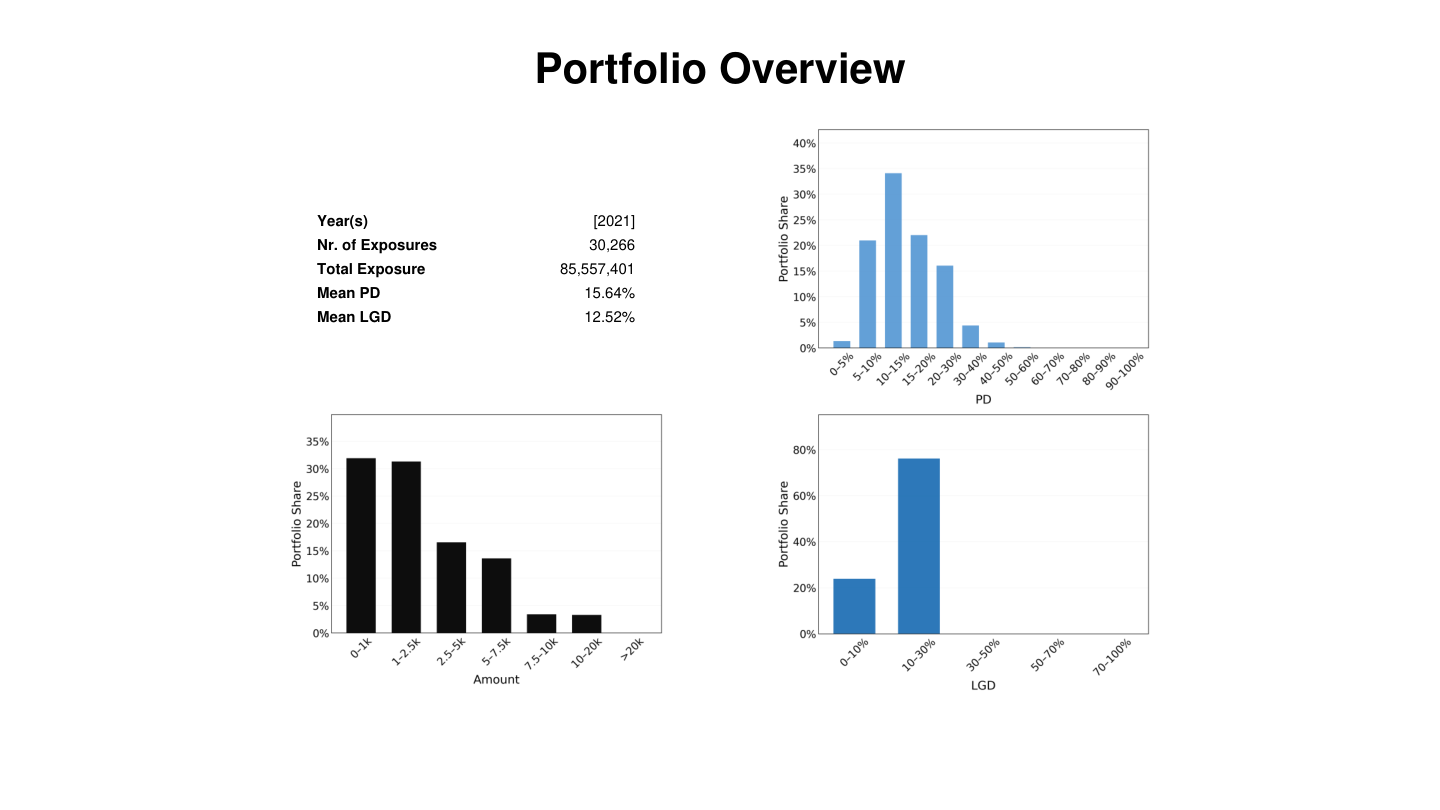

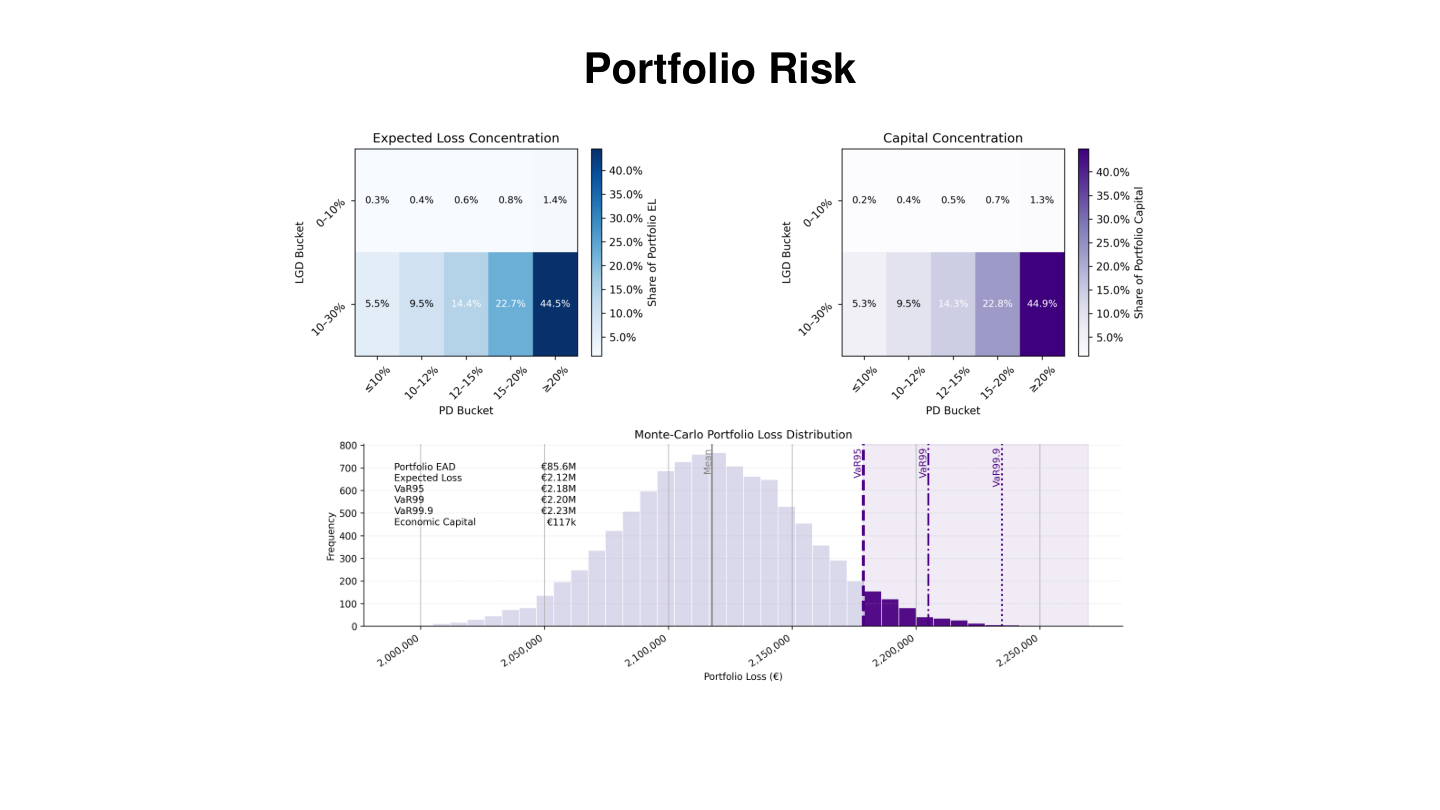

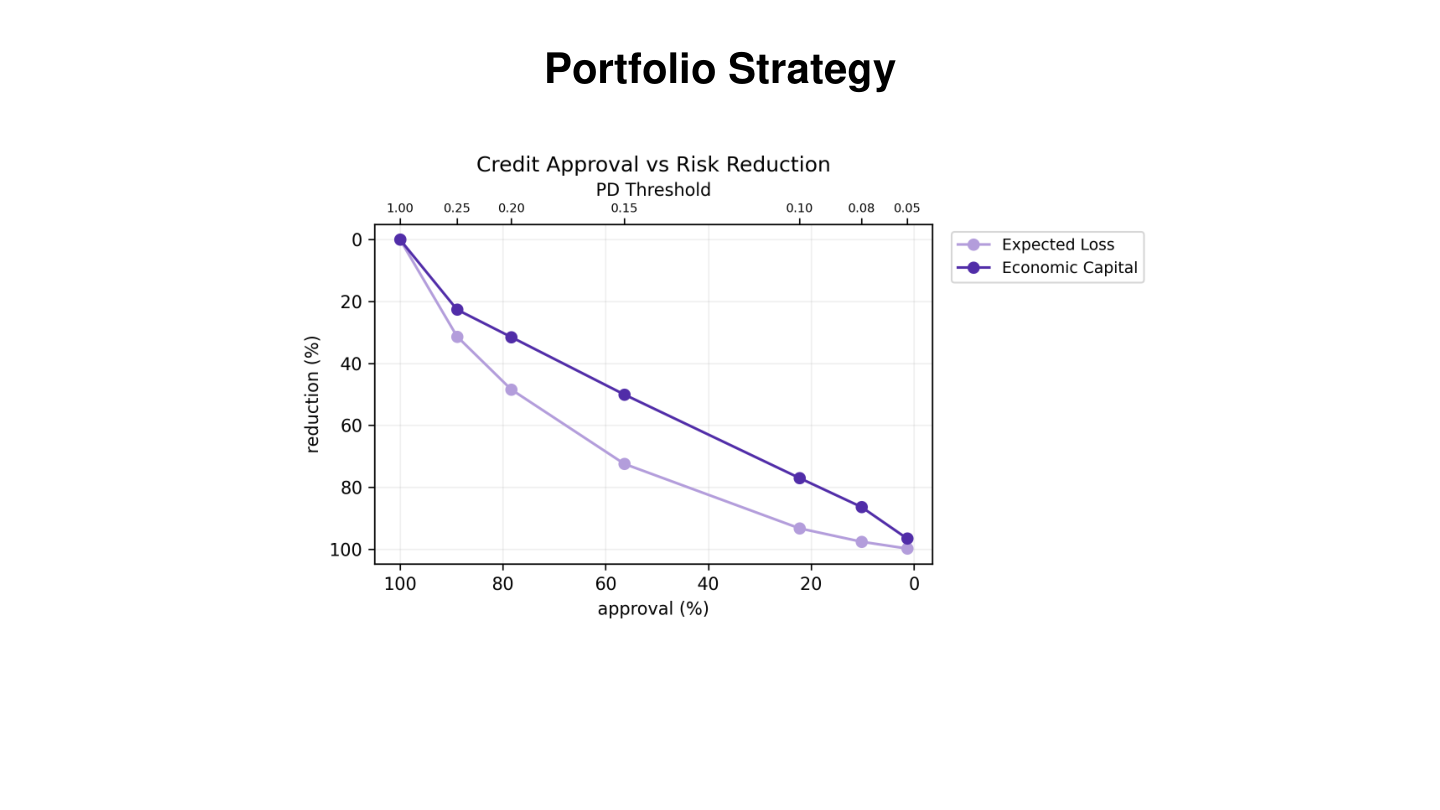

In [14]:
# optional pdf preview in notebook

import pymupdf
from IPython.display import display
from PIL import Image
import io

pdf_path = "../slides/reports/First_Report.pdf"
pdf = pymupdf.open(str(pdf_path))

for page in pdf:
    pix = page.get_pixmap(matrix=pymupdf.Matrix(1.5, 1.5))
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    display(img)